In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
%matplotlib inline

In [2]:
# Import data
df = pd.read_excel("/Users/nakyung/Desktop/Bioinformatics/Gilead/ARID1A Trop2 quantification.xlsx",
                   sheet_name=1, index_col=[0])

In [3]:
# Standardization of signal
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df[['ARID1A', 'Trop2']]), columns=['ARID1A', 'Trop2'])

In [4]:
# Perform Peason's correlation coefficienct analysis
r_value, p_value = pearsonr(df_standardized["ARID1A"], df_standardized["Trop2"])

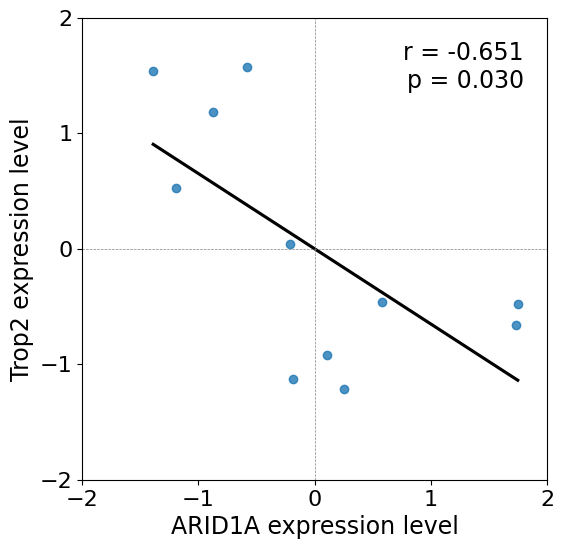

In [36]:
# Visualize the results
plt.figure(figsize=(6,6))
sns.regplot(x=df_standardized["ARID1A"], y=df_standardized["Trop2"], ci=None, line_kws={'color': 'black'})
plt.text(0.95, 0.95, f'r = {r_value:.3f}\np = {p_value:.3f}',
         transform=plt.gca().transAxes, verticalalignment="top", horizontalalignment="right",
         fontsize=17)
plt.yticks(np.arange(-2, 2.2, 1),fontsize = 16)
plt.xticks(np.arange(-2, 2.2, 1),fontsize = 16)
plt.xlabel("ARID1A expression level", fontsize = 17)
plt.ylabel("Trop2 expression level", fontsize = 17)
#plt.title("ARID1A expression - Trop2 expression\nPeason's Correlation", fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.5, linestyle="--")
plt.axvline(0, color="grey", linewidth=0.5, linestyle="--")

plt.savefig("/Users/nakyung/Desktop/Bioinformatics/Gilead/ARID1A Trop2 Pearson correlation.pdf", 
            format="pdf", dpi=300)